In [4]:
######################
# Load the fUSI data #
######################

import nibabel as nib
import numpy as np
from pathlib import Path
import tqdm
import matplotlib.pyplot as plt
import os

# Define the base path where your NIfTI files are stored
base_path = Path('/Users/clairenastaskin/data/sub-Forest003/ses-20251209/fusi/task-movements_run-001')
pwd_file_name  = 'sub-Forest003_ses-20251209_task-movements_run-001_pwd.nii.gz'
rigid_data = "fusi_data_rigid_reg.nii.gz"

pwd_path = base_path / pwd_file_name
rigid_path = base_path / rigid_data
# Load fUSI nifti file and get data into a numpy array
nifti_img = nib.load(pwd_path)
fusi_data = nifti_img.get_fdata()
fusi_data[np.isnan(fusi_data)] = 0 # set nan to 0
affine = nifti_img.affine
print(fusi_data.shape)

(171, 82, 141, 433)


In [8]:
fusi_rigid_nifti = nib.load(rigid_path).get_fdata()
fusi_rigid = fusi_rigid_nifti

fusi_data_mean = np.mean(fusi_rigid[:,:,:,30:300],-1)
print(fusi_data_mean.shape)
# save fusi_data_mean as nifti file
nifti_mean = nib.Nifti1Image(fusi_data_mean, affine)
nib.save(nifti_mean, base_path / 'fusi_data_mean.nii.gz')

(171, 82, 141)


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_71401/3024824729.py:13: RuntimeWarning: divide by zero encountered in log10
  fusi_data_dB = 10*np.log10(fusi_data)


29.462377133482573
dynamic range:  11.606182604058166


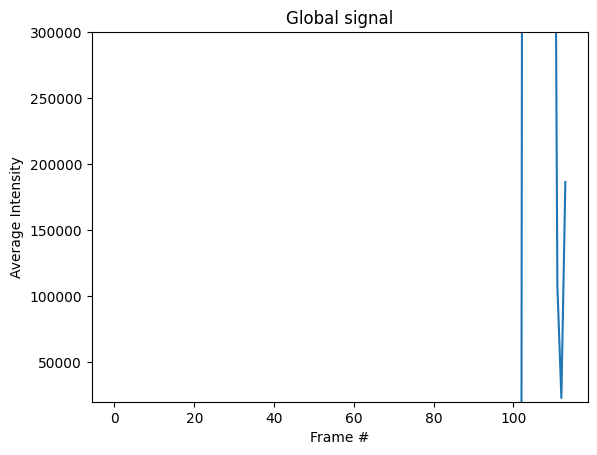

In [3]:
#######################################################################################
#     Display and save power Doppler movie, and display overall intensity over time   #
#######################################################################################

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

movie_path = base_path / "Doppler_movie.mp4"

if not movie_path.exists():
    # Convert to dB scale
    fusi_data_dB = 10*np.log10(fusi_data)
    nnz_idx = fusi_data > np.finfo(fusi_data.dtype).eps
    vmax = np.percentile(fusi_data_dB[nnz_idx], 90)
    vmin = np.percentile(fusi_data_dB[nnz_idx], 10)
    print(vmin)
    print('dynamic range: ', vmax-vmin)
    

    # Create animation
    fig, ax = plt.subplots()
    cax = ax.imshow(fusi_data_dB[:, fusi_data_dB.shape[1]//2, :, 0].T, cmap="inferno", extent=[0, 60, 42, 25], vmax=vmax+7, vmin=vmin)
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')
    ax.set_title("0")

    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")

    def update(frame):
        cax.set_data(fusi_data_dB[:, fusi_data_dB.shape[1]//2,:, frame].T)
        ax.set_title(f"Frame # {frame}")

    frames_to_plot = range(0, fusi_data_dB.shape[3], 1)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100)

    # Save the animation
    ani.save(movie_path, writer="ffmpeg")
    plt.close(fig)

# Display the saved movie
from IPython.display import Video
from IPython.display import display
display(Video(str(movie_path), embed=True, width=800, html_attributes="controls autoplay"))


global_signal = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(global_signal)
ax.set_title("Global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")
ax.set_ylim(20000,300000)
fig.savefig(base_path / "global_signal.png")

In [4]:
# deriv_global_signal = np.diff(global_signal)
# fig,ax = plt.subplots()
# ax.plot(deriv_global_signal)
# ax.set_title("Derivative of global signal")
# ax.set_xlabel("Frame #")
# ax.set_ylabel("Derivative of global signal")



In [5]:
##################################
## If we have accelorometer data ##
##################################


import zarr
import matplotlib.pyplot as plt
import numpy as np

# Open the zarr arrays
imu_path = base_path / next(base_path.glob('*_imu.zarr/accelerometer'))
acc_data = zarr.open(str(imu_path / 'values'), mode='r')
timestamps = zarr.open(str(imu_path / 'timestamps'), mode='r')

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each axis of acceleration vs timestamps
ax.plot(timestamps[:], acc_data[:, 0], label='X-axis')
ax.plot(timestamps[:], acc_data[:, 1], label='Y-axis')
ax.plot(timestamps[:], acc_data[:, 2], label='Z-axis')

# Customize plot
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration')
ax.set_title('Accelerometer Data')
ax.legend()
ax.grid(True)
plt.show()

fig.savefig(base_path / "imu_data.png")



StopIteration: 

frame_times:  [  1.902487   3.702517   5.502372   7.302359   9.102393  10.902527
  12.702408  14.502665  16.30248   18.102831  19.90271   21.702735
  23.502697  25.302638  27.102659  28.902872  30.702892  32.502798
  34.302999  36.102934  37.903058  39.703075  41.502737  43.302826
  45.103195  46.902944  48.702798  50.502984  52.303009  54.10297
  55.903002  57.702954  59.503271  61.303042  63.103059  64.902986
  66.703069  68.503183  70.30308   72.103064  73.903048  75.703072
  77.503194  79.302899  81.10318   82.903417  84.703153  86.503305
  88.303494  90.103198  91.903275  93.703198  95.503304  97.303224
  99.103007 100.903545 102.70325  104.503217 106.303341 108.103054
 109.903055 111.703439 113.503134 115.303405 117.103096 118.903346
 120.703352 122.503328 124.303342 126.10342  127.903481 129.703276
 131.503504 133.303414 135.103406 136.903485 138.703347 140.503333
 142.303537 144.103417 145.90354  147.703536 149.503295 151.303586
 153.103458 154.903421 156.703593 158.504103 160.

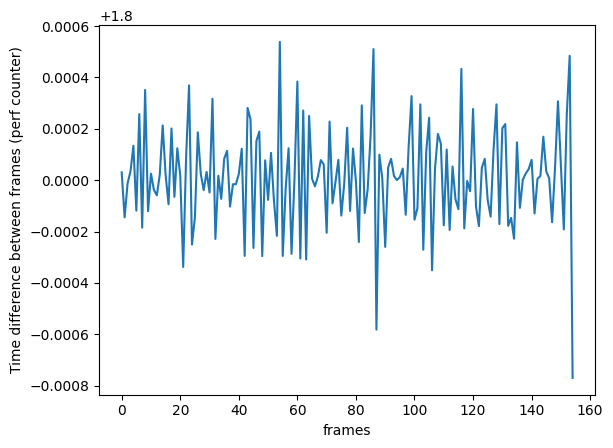

In [ ]:
#############################
# Import Forest1 json info #
############################
import json
from glob import glob
import numpy as np
import os

Forest1_info_file = base_path / "*pwd.json"
# Get the json file path using glob
info_file_path = glob(str(Forest1_info_file))[0]

# Read the json file
with open(info_file_path, 'r') as f:
    info = json.load(f)

frame_times = info['VolumeTiming']
frame_times = np.array(frame_times)
print('frame_times: ', frame_times)

diff_perf = np.diff(frame_times)
fig, ax = plt.subplots()
ax.plot(diff_perf)
ax.set_ylabel('Time difference between frames (perf counter)')
ax.set_xlabel('frames')
t_r = np.median(diff_perf)
t_r

# Save t_r value to base_path
np.save(os.path.join(base_path, 't_r.npy'), t_r)
fig.savefig(base_path / "time_between_frame.png")

In [ ]:
# ##############################################
# # Extract Psychotria time_stamps #
# ##############################################
import pandas as pd

if os.path.exists(base_path / 'task_events.tsv'):
    task_path = base_path / 'task_events.tsv'
else:
    task_path = list(base_path.glob('*events.tsv'))[0]
task_events = pd.read_csv(task_path, sep='\t')

task_events

,onset,duration,trial_type,response_time,control,task,late_start,early_finish
0,11.65377,15.382,Bounce_chair_1.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
1,42.03677,17.288,Yes_shake_head_1.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
2,74.32677,15.360,Bounce_chair_2.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
3,104.68677,16.396,wobble_your_head_1.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
4,136.08377,16.388,wobble_your_head_2.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
5,167.47277,25.377,sing_muse_3.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
6,207.85077,17.289,Yes_shake_head_2.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
7,240.13977,23.999,sing_muse_4.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN


In [ ]:
# #########################################################
# #   Replace trial type names to remove number suffixes  #
# #########################################################

# # If needed, replace the events
# # Replace values using .loc and .str.contains
# task_events.loc[task_events['trial_type'].str.contains('_Hap', case=False, na=False), 'trial_type'] = 'face_happy'
# task_events.loc[task_events['trial_type'].str.contains('_fear', case=False, na=False), 'trial_type'] = 'face_fear'
# task_events.loc[task_events['trial_type'].str.contains('_Fear', case=False, na=False), 'trial_type'] = 'face_fear'
# task_events.loc[task_events['trial_type'].str.contains('CloseYourEyes', case=False, na=False), 'trial_type'] = 'CloseYourEyes'

# # If needed, replace the events
# Replace values using .loc and .str.contains
# task_events.loc[task_events['trial_type'].str.contains('sing_muse', case=False, na=False), 'trial_type'] = 'sing'
# task_events.loc[task_events['trial_type'].str.contains('Yes_shake', case=False, na=False), 'trial_type'] = 'Yes_shake_head'
# task_events.loc[task_events['trial_type'].str.contains('wobble', case=False, na=False), 'trial_type'] = 'wobble_head'
# task_events.loc[task_events['trial_type'].str.contains('Bounce_chair', case=False, na=False), 'trial_type'] = 'bounce_chair'

# task_events.trial_type = "song_played"
task_events

,onset,duration,trial_type,response_time,control,task,late_start,early_finish
0,11.65377,15.382,Bounce_chair_1.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
1,42.03677,17.288,Yes_shake_head_1.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
2,74.32677,15.360,Bounce_chair_2.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
3,104.68677,16.396,wobble_your_head_1.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
4,136.08377,16.388,wobble_your_head_2.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
5,167.47277,25.377,sing_muse_3.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
6,207.85077,17.289,Yes_shake_head_2.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN
7,240.13977,23.999,sing_muse_4.mp4,NaN,False,motion_artefact_2_v2,NaN,NaN


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5728/3822447683.py:21: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  average_over_time_detrended = clean(


Indexes to mask =  [ 11  12  14  24  25  26  27  28  29  30  31  32  42  43  44  45  46  47
  48  49  50  52  58  59  60  61  62  63  64  65  66  67  76  77  78  79
  80  81  82  83  84 116 117 118 119 120 121 122 123 124 125]
(105,)


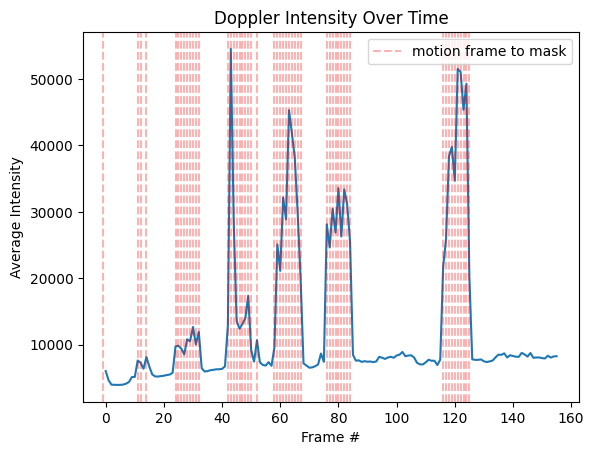

In [ ]:
##########################################################################################
#     Display Doppler intensity time course and create a sample_masks for motion frames  #
##########################################################################################

from nilearn.signal import clean

average_over_time = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(average_over_time)
ax.set_title("Doppler Intensity Over Time")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")


###################################################
# Detrend the time course to remove linear trends #
###################################################

# Reshape to 2D array since clean expects samples x features
average_over_time_2d = average_over_time.reshape(-1, 1)
average_over_time_detrended = clean(
    average_over_time_2d,
    detrend=True,
    t_r=t_r,
)
# Convert back to 1D array
average_over_time_detrended = average_over_time_detrended.ravel()

#######################################################################################################################
# Based on detrended signal, find motion frames (here defined as frames with values higher than median + 5 times std) #
#######################################################################################################################
median_detrended_signal=np.median(average_over_time_detrended)
perc_50 = np.percentile(average_over_time_detrended,50)
perc_50_signal = average_over_time_detrended[average_over_time_detrended < perc_50]
std_perc_50 = np.std(perc_50_signal)

# Find frames with values > median + 5*std of lower 50% of signal
index_to_mask = np.where(average_over_time_detrended > (median_detrended_signal + 3*std_perc_50))[0]
# Add vertical lines for motion frames
for frame in index_to_mask:
    ax.axvline(x=frame, color='r', linestyle='--', alpha=0.3)
ax.axvline(x=-1, color='r', linestyle='--', alpha=0.3, label='motion frame to mask')
ax.legend()
print('Indexes to mask = ', index_to_mask)

#############################
#     Create sample_masks  #
############################
sample_masks = np.zeros(fusi_data.shape[3] - len(index_to_mask), dtype=int)
t = 0
for i in range(fusi_data.shape[3]):
    if i not in index_to_mask:
        sample_masks[t] = i
        t += 1

print(sample_masks.shape)
fig.savefig(base_path / "global_signal_with_masked_frame.png")

In [ ]:
# # # ################################
# # # # Plot temperature time course #    
# # # ################################

# temp_log= info['ProbeTemperature'] 


# fig,ax = plt.subplots()
# ax.plot(temp_log)
# ax.set_title('Interposer temperature')
# ax.set_xlabel('Frame (s)')
# ax.set_ylabel('Frame #')
# plt.show()
# fig.savefig(base_path / "interposer_temperature.png")

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Median frame index: 148


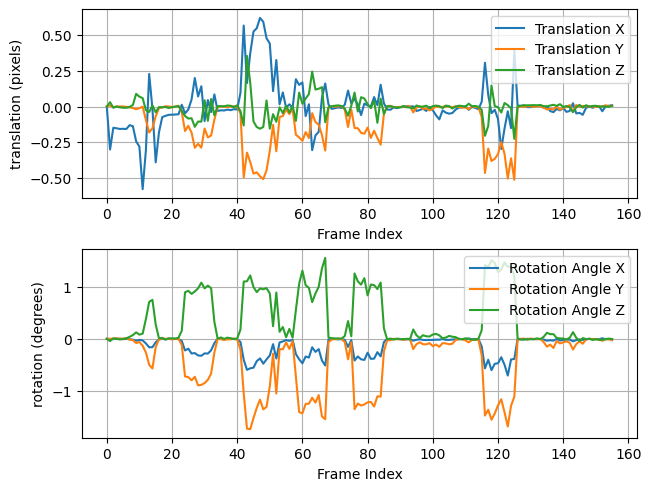

In [ ]:
# #########################################
# #######  Rigid transformation  #########
# ########################################
import fusi_utils_BIDS as utils

transformation_file = base_path / "rigid_transformations.nii.gz"
affine = nifti_img.affine

if not transformation_file.exists():
    fusi_data_rigid_reg, rigid_transformations = utils.register_3d_image_stack(fusi_data)
    
    # Save rigid transformations to file
    nib.save(nib.Nifti1Image(rigid_transformations, affine), transformation_file)
    nib.save(nib.Nifti1Image(fusi_data_rigid_reg, affine), base_path / "fusi_data_rigid_reg.nii.gz")
else:
    # Load rigid transformations from file
    rigid_transformations = nib.load(transformation_file).get_fdata()
    fusi_data_rigid_reg = nib.load(base_path / "fusi_data_rigid_reg.nii.gz").get_fdata()

# Plot rigid_transformations
fig, axes = plt.subplots(nrows=2, ncols=1,layout="constrained")
ax_tran=axes[0]
ax_tran.plot(rigid_transformations[0, :], label="Translation X")
ax_tran.plot(rigid_transformations[1, :], label="Translation Y")
ax_tran.plot(rigid_transformations[2, :], label="Translation Z")
ax_tran.set_xlabel("Frame Index")
ax_tran.set_ylabel("translation (pixels)")
ax_tran.legend()
ax_tran.grid(True)
ax_tran.legend()

ax_rot=axes[1]
ax_rot.plot(rigid_transformations[3, :] * 180 / np.pi, label="Rotation Angle X")
ax_rot.plot(rigid_transformations[4, :] * 180 / np.pi, label="Rotation Angle Y")
ax_rot.plot(rigid_transformations[5, :] * 180 / np.pi, label="Rotation Angle Z")
ax_rot.set_xlabel("Frame Index")
ax_rot.set_ylabel("rotation (degrees)")
ax_rot.legend()
ax_rot.grid(True)
ax_rot.legend()

# Save figure
fig.savefig(base_path / "registration.png")
# plt.close()


In [ ]:
######################################################################
#     Display and save power Doppler movie after rigid registration  #
######################################################################

movie_file = base_path / "Doppler_movie_after_rigid_registration.mp4"

if not movie_file.exists():
    fusi_data_rigid_reg_dB = 10*np.log10(fusi_data_rigid_reg)
    nnz_idx = fusi_data_rigid_reg > np.finfo(fusi_data_rigid_reg.dtype).eps
    vmax = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 90)
    vmin = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 10)
    print(vmin)
    print('dynamic range: ', vmax-vmin)

    # Create figure and initial plot
    fig, ax = plt.subplots()
    cax = ax.imshow(
        fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, 0].T,
        cmap="inferno",
        vmax=vmax+7, vmin=vmin,
        extent=[0, 50, 42, 25],
    )
    ax.set_title("0")

    # Set axis labels
    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')

    def update(frame):
        cax.set_data(
            fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, frame].T
        )
        ax.set_title(f"Frame # {frame}")
        return (cax,)

    # Create a list of frames to plot every other frame
    frames_to_plot = range(0, fusi_data_rigid_reg.shape[3], 2)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100, blit=True)

    # Save the animation as an MP4 file
    ani.save(movie_file, writer="ffmpeg")
    plt.close()
    display(HTML(ani.to_jshtml()))

else:
    # Display the saved movie
    from IPython.display import Video
    from IPython.display import display
    display(Video(str(movie_file), embed=True, width=800, html_attributes="controls autoplay"))



/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5728/691063805.py:8: RuntimeWarning: divide by zero encountered in log10
  fusi_data_rigid_reg_dB = 10*np.log10(fusi_data_rigid_reg)


36.6834279028275
dynamic range:  9.536904555071267


/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/first_level/experimental_paradigm.py:177: UserWarning: The following unexpected columns in events data will be ignored: task, control, early_finish, response_time, late_start
  warnings.warn(
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5728/2473731762.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 640x480 with 0 Axes>

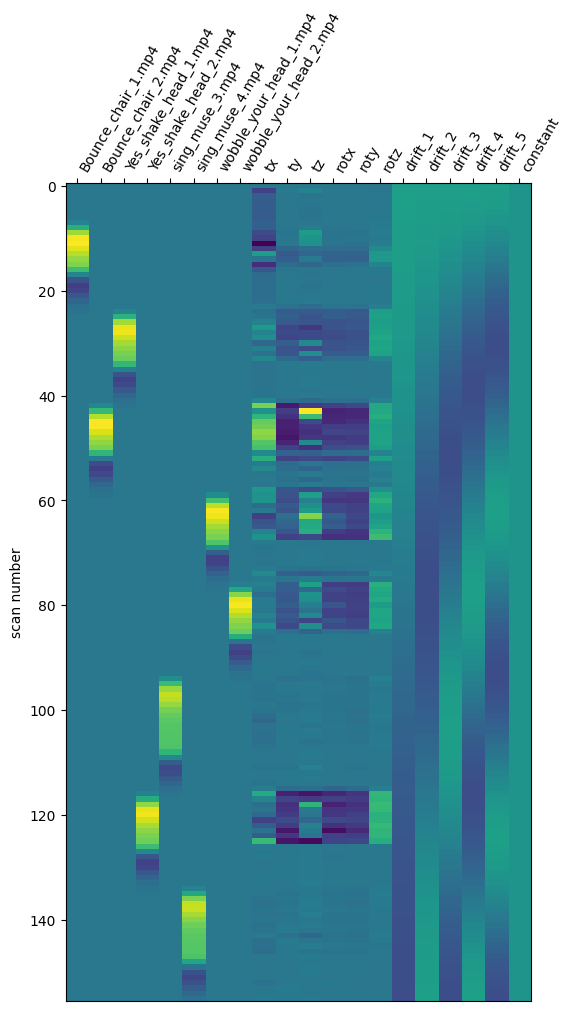

In [ ]:
#######################################
#     Create design matrix for GLM    #
#######################################
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import os

fusi_data = fusi_data_rigid_reg  # If we're happy about the registration
regressed_with_transformations = True

event_time_offset =  0 #t_r #t_r # in seconds 
task_events["onset"] += event_time_offset

if regressed_with_transformations:
    events_df = make_first_level_design_matrix(
        frame_times,
        task_events,
        drift_model="cosine", 
        high_pass=0.01,
        add_regs=rigid_transformations.transpose(),
        add_reg_names=["tx", "ty", "tz", "rotx", "roty", "rotz"],
        hrf_model="glover",
    )
else:
    events_df = make_first_level_design_matrix(
        frame_times,
        task_events,
        drift_model="cosine",
        high_pass=0.01,
        hrf_model="glover",
    )


design_matrix = events_df
fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

# Save design matrix as .npz file
np.savez(os.path.join(base_path, 'design_matrix.npz'), design_matrix=design_matrix.values, column_names=design_matrix.columns)

In [ ]:
###########################################
# Temporal smoothing and convert to NIfTI #
###########################################
import fusi_utils_BIDS as utils

from nilearn.signal import butterworth
window_size = 3  # Number of time points for smoothing
pd = utils.boxcar_smooth(fusi_data, window_size)

# Create a NIfTI image object from our processed data (pd) and the affine matrix
fusi_img = nib.Nifti1Image(pd, affine)
fusi_img.to_filename(base_path / "fUSi_data_after_processing.nii.gz")
fusi_img.shape

(123, 59, 46, 156)

In [ ]:
###########
# Fit GLM #
##########
import pandas as pd
from nilearn.glm.first_level import FirstLevelModel
from nilearn.masking import compute_epi_mask, apply_mask

smoothing_fwhm = (2) # 0 spatial smoothing in pixel to apply to the data before computing GLM

# Filter sample_masks to only include values up to fusi_img.shape[3]
sample_masks = sample_masks[sample_masks <= fusi_img.shape[3]-1]

# Create binary mask: include voxels that are non-zero at the first timepoint
mask_array = (fusi_data[..., 0] != 0).astype(np.uint8)
mask_img = nib.Nifti1Image(mask_array, affine)

# Initialize and fit the GLM model with specified parameters
print("Fitting a GLM")
fusi_glm = FirstLevelModel(
    t_r=t_r,
    minimize_memory=False,
    mask_img=mask_img,
    smoothing_fwhm=smoothing_fwhm,
    standardize=True,
)

# if we want to include global signal as a confound uncomment the two lines below : 
# confounds = pd.DataFrame({"global_signal": global_signal}) # if we want to include global signal as a confound
# fusi_glm = fusi_glm.fit(fusi_img, design_matrices=design_matrix, sample_masks=[sample_masks],confounds=confounds)


fusi_glm = fusi_glm.fit(fusi_img, design_matrices=design_matrix, sample_masks=[sample_masks])


Fitting a GLM


In [ ]:
##########################################
## Create contrasts for localizer task ##
##########################################

def make_localizer_contrasts(design_matrix):
    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        column: contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }
    # contrasts["right_fingers_minus_singing"] = (
    #     contrasts["Right fingers"]
    #     - contrasts["Singing"])
    # contrasts["right_foot_minus_singing"] = (
    #     contrasts["Right foot"]
    #     - contrasts["Singing"])
    # contrasts["right_wrist_minus_singing"] = (
    #     contrasts["Right wrist"]
    #     - contrasts["Singing"])
    return contrasts
    
contrasts = make_localizer_contrasts(design_matrix)
print("Contrasts:")
for name in [k for k in contrasts.keys() if 'drift' not in k]:
    print(f"- {name}")

Contrasts:
- Bounce_chair_1.mp4
- Bounce_chair_2.mp4
- Yes_shake_head_1.mp4
- Yes_shake_head_2.mp4
- sing_muse_3.mp4
- sing_muse_4.mp4
- wobble_your_head_1.mp4
- wobble_your_head_2.mp4
- tx
- ty
- tz
- rotx
- roty
- rotz
- constant


Computing contrasts
	contrast id: Bounce_chair_1.mp4


/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/plotting/displays/_slicers.py:313: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


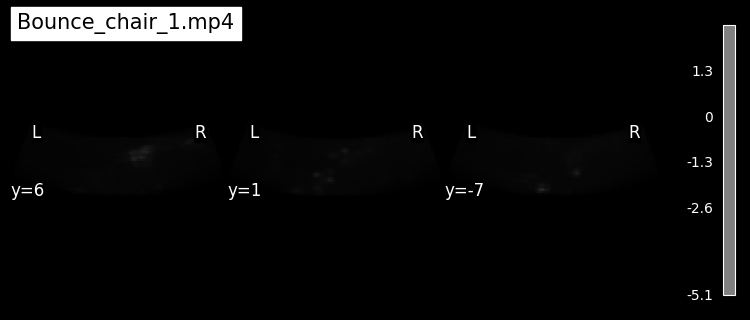

	contrast id: Bounce_chair_2.mp4


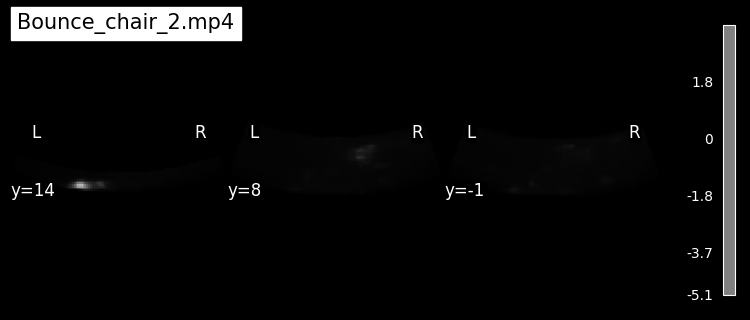

	contrast id: Yes_shake_head_1.mp4


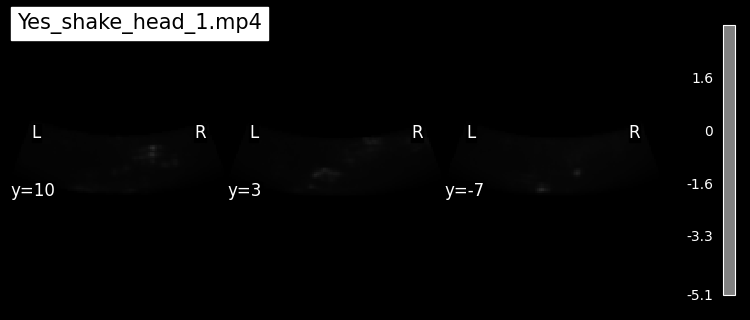

	contrast id: Yes_shake_head_2.mp4


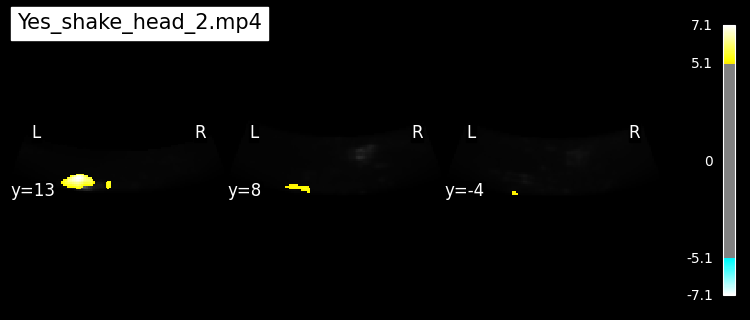

	contrast id: sing_muse_3.mp4


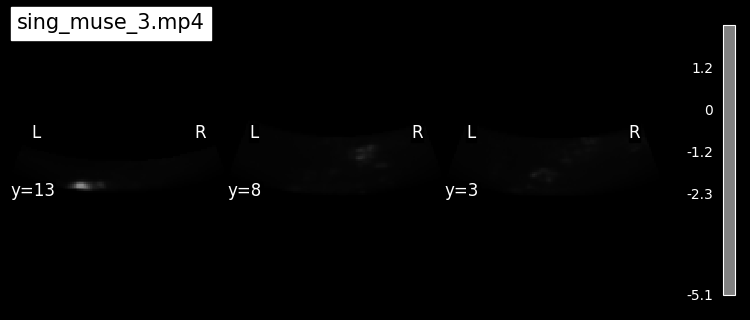

	contrast id: sing_muse_4.mp4


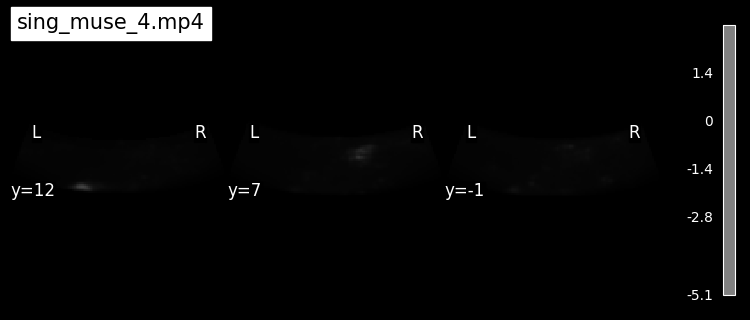

	contrast id: wobble_your_head_1.mp4


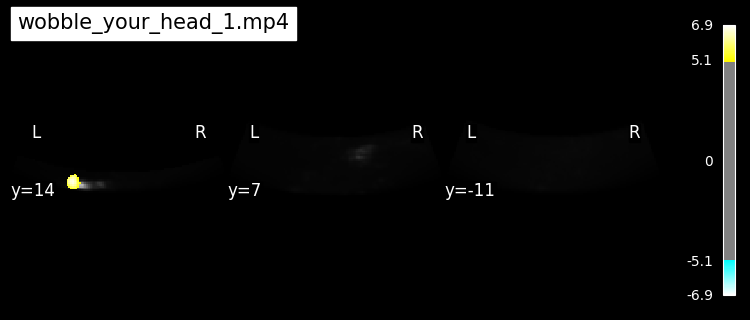

	contrast id: wobble_your_head_2.mp4


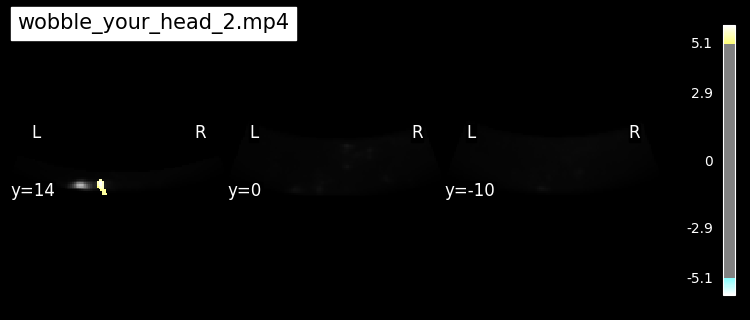

In [ ]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img
import scipy.io
import os
import nibabel as nib
import numpy as np

print("Computing contrasts")
mean_image = nib.Nifti1Image(
    np.mean(fusi_img.get_fdata(), axis=-1), fusi_img.affine
)
os.makedirs(base_path, exist_ok=True)  # Create the directory if it doesn't exist


########################
# Iterate on contrasts #
########################

from nilearn.masking import unmask

for contrast_id, contrast_val in {k: v for k, v in contrasts.items() if k not in ['tx', 'ty', 'tz', 'rotx', 'roty', 'rotz', 'constant'] and not k.startswith('drift')}.items():    
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fusi_glm.compute_contrast(contrast_val, output_type="stat")

    # Get the data from z_map and create new NIfTI image
    z_map_data = z_map.get_fdata()
    nii_zmap = nib.Nifti1Image(z_map_data, affine)
    # Save the NIfTI zmap to a compressed .nii.gz file in the base_path
    output_path = os.path.join(base_path, f"{contrast_id}_z_map.nii.gz")
    nib.save(nii_zmap, output_path)

    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fusi image
    # a threshold of 2.58 is used (corresponding to p < 0.01)
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=5.1,
        cut_coords=3,
        display_mode="y",
        black_bg=True,
        title=contrast_id
    )
    plotting.show()

In [ ]:
#######################################################################################
#  Extract time series of clusters with z-scores > 3.1 and display their time courses #
#######################################################################################
import pandas as pd
# Create probe events DataFrame with time_stamp column
probe_events = pd.DataFrame(columns=['time_stamp'])
probe_events['time_stamp'] = frame_times


contrast = "Audio no speech"
threshold = 1
roi_radius = 3
[z_map, coords, real_timecourse, predicted_timecourse] = (
    utils.extract_time_course_from_main_clusters(
        contrast,
        threshold,
        sample_masks,
        fusi_img,
        fusi_glm,
        probe_events,
        t_r,
        roi_radius
    )
)
# coords = [(77,29,26), (64,55,48)]
utils.display_real_and_predicted_timecourses(contrast,real_timecourse, predicted_timecourse,task_events, coords, z_map, mean_image)
# utils.display_predicted_timecourses(contrast, predicted_timecourse,task_events, coords, z_map, mean_image)

ValueError: The expression (Audio no speech) is not valid. This could be due to defining the contrasts using design matrix columns that are invalid python identifiers.

In [ ]:
#######################################
#  Extract time series of regressors #
######################################
contrast = "drift_1"

utils.display_regressor_temporal_component(
    contrast,
    fusi_glm=fusi_glm,
    probe_events=probe_events,
    t_r=t_r,
    sample_masks=sample_masks,
    task_events=task_events,
)


/Users/clairenastaskin/Documents/Anise/Experiments/fusi_utils_BIDS.py:1322: UserWarning: Attention: No clusters with stat higher than 2
  table = get_clusters_table(z_map, stat_threshold=2, cluster_threshold=5)


KeyError: "None of [Index([0], dtype='int64')] are in the [index]"